# **(ADD THE NOTEBOOK NAME HERE)**

## Objectives

* Write your notebook objective here, for example, "Fetch data from Kaggle and save as raw data", or "engineer features for modelling"

## Inputs

* Write down which data or information you need to run the notebook 

## Outputs

* Write here which files, code or artefacts you generate by the end of the notebook 

## Additional Comments

* If you have any additional comments that don't fit in the previous bullets, please state them here. 



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/Users/nav/Desktop/Project 1/credit_card_analysis/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'/Users/nav/Desktop/Project 1/credit_card_analysis'

# Importing libraries and cleaned data

In [4]:
#import the the libraries i will be using for this project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [5]:
df_clean = pd.read_csv('Dataset/CleanedData/BankChurners_cleaned.csv')
df_clean.head() # Checking the first 5 rows of the cleaned dataset 

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,0,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,0,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,0,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,0,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,0,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


---

# Data Visualisation

# Hypothesis 1 (plotly)
Customers who have been with the bank longer have a higher credit limit

In [6]:
# check the correlation between 'months_on_book' and 'Credit_Limit' using a scatter plot
df_clean[['Months_on_book', 'Credit_Limit']].corr()

,Months_on_book,Credit_Limit
Months_on_book,1.000000,0.007507
Credit_Limit,0.007507,1.000000


In [7]:
fig = px.scatter(
    df_clean,
    x='Months_on_book',
    y='Credit_Limit',
    title='Relationship Between Months with Bank and Credit Limit',
    labels={
        'Months_on_book': 'Months with Bank',
        'Credit_Limit': 'Credit Limit (£)'
    },
)
fig.show()

In [8]:
average_credit = df_clean.groupby('Months_on_book')['Credit_Limit'].mean().round(2)

fig = px.line(
    average_credit,
    x=average_credit.index,
    y=average_credit.values,
    title='Average Credit Limit by Months with Bank',
    labels={
        'x': 'Months with Bank',
        'y': 'Average Credit Limit (£)'
    },
)
fig.show()

---

# Hypothesis 2 (Matplotlib)

Customers with more bank products are less like to churn 


In [9]:
relationship_mean = df_clean.groupby('Attrition_Flag')['Total_Relationship_Count'].mean()
print(relationship_mean)

Attrition_Flag
0    3.914588
1    3.279656
Name: Total_Relationship_Count, dtype: float64


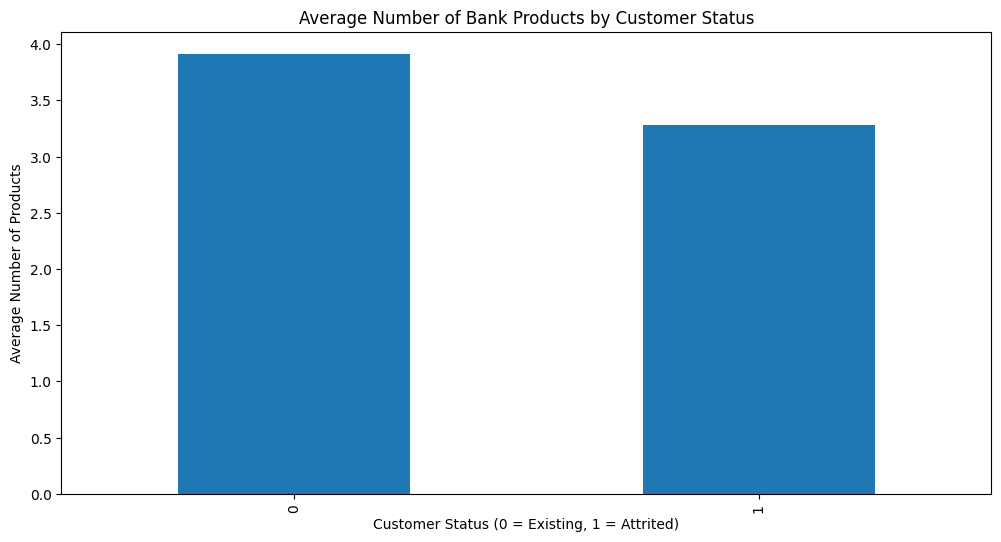

In [10]:
plt.figure(figsize=(12,6))

relationship_mean.plot(kind='bar')

plt.title('Average Number of Bank Products by Customer Status')
plt.xlabel('Customer Status (0 = Existing, 1 = Attrited)')
plt.ylabel('Average Number of Products')

plt.show()




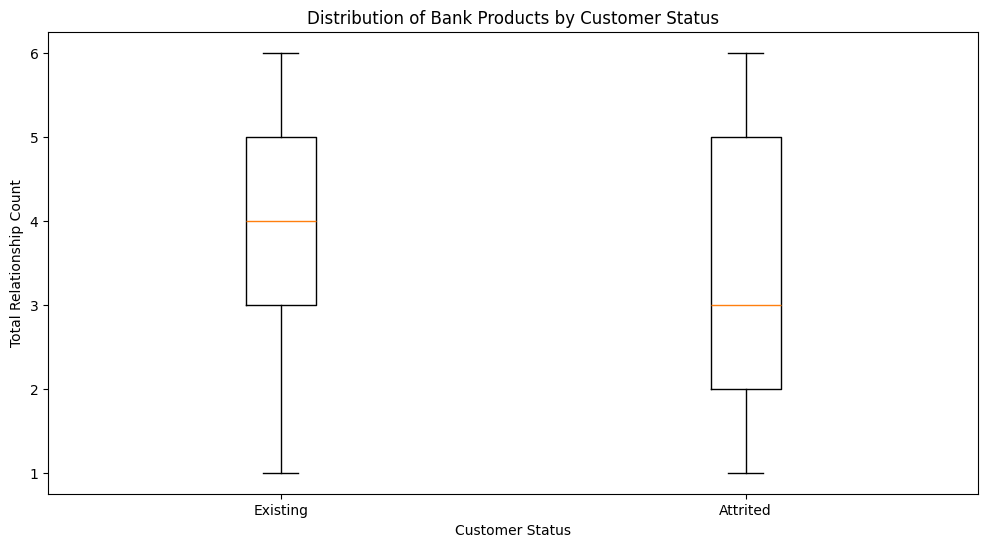

In [11]:
plt.figure(figsize=(12,6))
existing = df_clean[df_clean['Attrition_Flag'] == 0]['Total_Relationship_Count']
attrited = df_clean[df_clean['Attrition_Flag'] == 1]['Total_Relationship_Count']

plt.boxplot(
    [existing, attrited],
    labels=['Existing', 'Attrited']
)

plt.title('Distribution of Bank Products by Customer Status')
plt.xlabel('Customer Status')
plt.ylabel('Total Relationship Count')

plt.show()

# Hypothesis 3 (seaborn)

Customers with more inactive months are more likely to churn

In [15]:
inactive_mean = df_clean.groupby('Attrition_Flag')['Months_Inactive_12_mon'].mean().round(2)
print(inactive_mean)

Attrition_Flag
0    2.27
1    2.69
Name: Months_Inactive_12_mon, dtype: float64


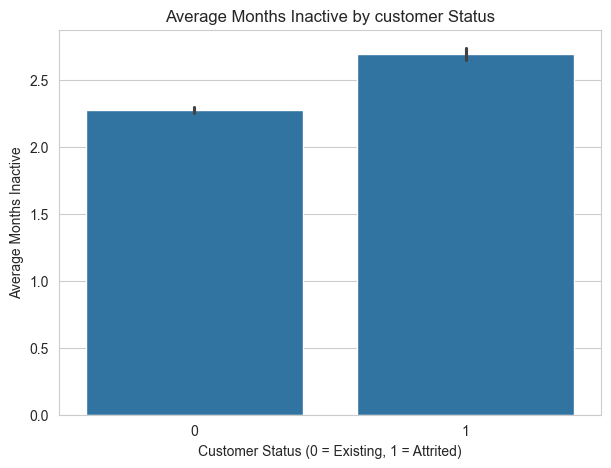

In [19]:
sns.set_style('whitegrid')
plt.figure(figsize=(7,5))

sns.barplot(data=df_clean, x='Attrition_Flag', y='Months_Inactive_12_mon')
plt.title('Average Months Inactive by customer Status')
plt.xlabel('Customer Status (0 = Existing, 1 = Attrited)')
plt.ylabel('Average Months Inactive')

plt.show()

# Hypothesis 4 (Plotly)

NOTE

* You may add as many sections as you want, as long as it supports your project workflow.
* All notebook's cells should be run top-down (you can't create a dynamic wherein a given point you need to go back to a previous cell to execute some task, like go back to a previous cell and refresh a variable content)

---

# Push files to Repo

* In cases where you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [12]:
import os
try:
  # create your folder here
  # os.makedirs(name='')
except Exception as e:
  print(e)


IndentationError: expected an indented block after 'try' statement on line 2 (553063055.py, line 5)